In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import torch
import copy
from matplotlib.colors import hsv_to_rgb
import pandas as pd
import matplotlib as mpl
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
from matplotlib.widgets import Slider
from scipy.ndimage import gaussian_filter1d
import bisect

In [2]:
data = pd.read_csv("\\\\NAS_LOCCO\\Amaury\\DATA\\4_polar_MFM_these\\2026_02_02_W.csv", delimiter=';')
frame = data['frame'].to_numpy().astype(int)
x = data['x']
y = data['y']
z = data['z']
rho = data['rho']
eta = data['eta']
delta = data['delta']
N_photons = data['N_photon']
score = data['score']
x_start = data['x_start']
y_start = data['y_start']
z_start = data['z_start']
rho_start = data['rho_start']
delta_start = data['delta_start']

In [3]:
len(x)

5813

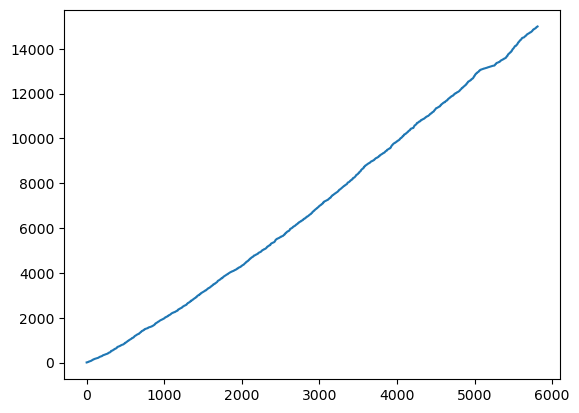

In [6]:
%matplotlib inline
hh = plt.plot(frame)

In [7]:
eta90 = copy.deepcopy(eta)
for ii in range(len(eta90)):
    if eta90[ii]>90:
        eta90[ii] = 180.-eta90[ii]

Text(0, 0.5, 'Occurences')

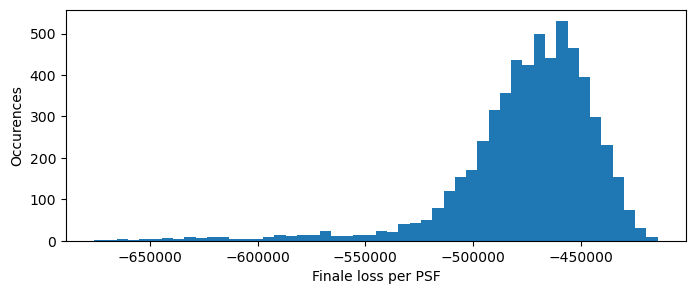

In [8]:
plt.rcParams['figure.figsize'] = [8,3]
hist = plt.hist(score, bins=50)
plt.xlabel('Finale loss per PSF')
plt.ylabel('Occurences')

Text(0, 0.5, 'Occurences')

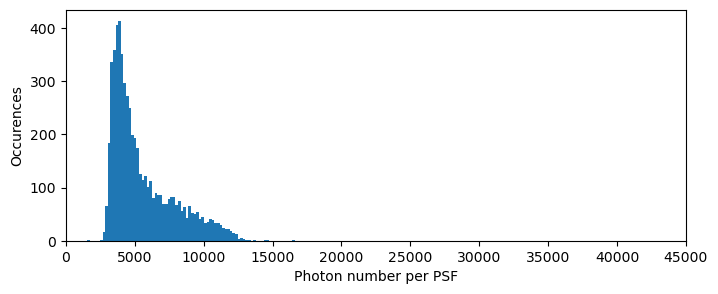

In [9]:
plt.rcParams['figure.figsize'] = [8,3]
hist = plt.hist(N_photons, bins=80)
plt.xlim((0, 45000))
plt.xlabel('Photon number per PSF')
plt.ylabel('Occurences')

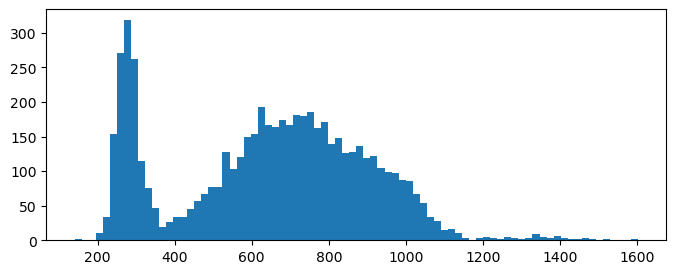

In [10]:
hist = plt.hist(z, bins=80)

In [11]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot()
vals = frame
sc = ax.scatter(x , y , c=vals , cmap='coolwarm', s=10)
ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()
points = np.column_stack((x, y))
mask = np.zeros(len(x), dtype=bool)

def onselect(verts):
    global mask
    path = Path(verts)
    mask = path.contains_points(points) 
    print(mask)

lasso = LassoSelector(ax, onselect)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


[ True  True False ... False  True  True]


In [12]:
def mean_x_per_20_frames(x, frame, window=20):

    bins = (frame // window).astype(int)
    n_bins = bins.max() + 1

    sum_x = np.bincount(bins, weights=x, minlength=n_bins)
    count = np.bincount(bins, minlength=n_bins)

    mean_x = np.zeros(n_bins)

    nonzero = count > 0
    mean_x[nonzero] = sum_x[nonzero] / count[nonzero]

    mean_x[~nonzero] = np.nan  # only real empty bins

    return mean_x

In [13]:
mean_x = mean_x_per_20_frames(x[mask], frame[mask], 40)
mean_y = mean_x_per_20_frames(y[mask], frame[mask], 40)

In [14]:
for i in range(len(mean_x)):
    if np.isnan(mean_x[i]):
        mean_x[i] = (mean_x[i-1]+mean_x[i+1])/2
        mean_y[i] = (mean_y[i-1]+mean_y[i+1])/2

In [15]:
np.isnan(mean_x).any()
np.isnan(mean_y).any()

False

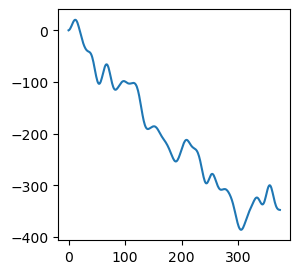

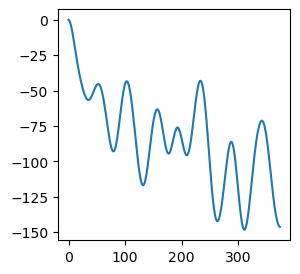

In [16]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [3,3]
xcorr = gaussian_filter1d(mean_x, 7)
xcorr = xcorr-xcorr[0]
plt.plot(xcorr)
plt.show()
ycorr = gaussian_filter1d(mean_y, 11)
ycorr = ycorr-ycorr[0]
plt.plot(ycorr)

In [17]:
frame_bins = np.linspace(0, np.max(frame), len(xcorr)).astype(int)

In [18]:
for ind, frame_ in enumerate(frame):
    idx = bisect.bisect_left(frame_bins, frame_)
    #print(frame_, idx, frame_bins[idx-1])
    x[ind]-=xcorr[idx-1]
    y[ind]-=ycorr[idx-1]
    #print(ind, frame_, x[ind], y[ind], xcorr[idx-1]*0.45, ycorr[idx-1]*0.6)

In [59]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [15,15]
fig = plt.figure()
ax = fig.add_subplot()
vals = frame
sc = ax.scatter(x , y , c=vals , cmap='coolwarm', s=10)
ax.axis('equal')
cb = plt.colorbar(sc)
cb.ax.invert_yaxis()
points = np.column_stack((x, y))
mask = np.zeros(len(x), dtype=bool)

def onselect(verts):
    global mask
    path = Path(verts)
    mask = path.contains_points(points) 
    print(mask)

lasso = LassoSelector(ax, onselect)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[ True  True False ... False  True  True]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


[False False  True ...  True False False]


In [60]:
loss_thresh = -30000
maskdelta = (score<loss_thresh) & (N_photons>2000) & (N_photons<9000) & (z<1200) & (z>0)
mask1 = mask &(score<loss_thresh) & (delta<150) & (N_photons>2000) & (N_photons<9000) & (z<1200) & (z>100)
zoom = (score<loss_thresh) & (delta<150) & (N_photons>2000) & (N_photons<9000) & (x>5000) & (x<12000) & (y>-18000) & (y<-4000) & (z<500) & (z>100)

threshold = (score<-430000) & (delta<150) & (x>17500) & (x<200000) & (y>2000) & (y<5500) & (z<1450) & (N_photons<85000) & (N_photons>6000) 
threshold2 = (score<-430000) & (delta<150) & (x>10000) & (x<22500) & (y>2000) & (y<15000) & (N_photons<85000) & (N_photons>6000) 
threshold3 = (score<-430000) & (delta<150) & (x>10000) & (x<22500) & (y>2000) & (y<15000) & (z<1450) & (N_photons<85000) & (N_photons>6000) 
threshold4 = (score<-430000) & (N_photons<85000) & (N_photons>6000) 

In [63]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams.update({'font.size': 15})
hues = rho[mask1] / 180.0
hsv_colors = np.stack((hues, np.ones_like(hues), np.ones_like(hues)), axis=1)
rgb_colors = hsv_to_rgb(hsv_colors)
plt.scatter(x[mask1]/1000, y[mask1]/1000, c=rgb_colors, s=2)
plt.axis('equal')
#plt.xlim((10000, 22500))
#plt.ylim((2200, 14000))
plt.xlabel('x ($\\mu$m)')
plt.ylabel('y ($\\mu$m)')

# Half-circle colorbar rotated 90° clockwise
center_x, center_y = 8, -15
radius = 0.2
angles = np.linspace(0, np.pi, 200)  # rotated arc
for i in range(len(angles)-1):
    theta1, theta2 = angles[i], angles[i+1]
    hue = (np.degrees(theta1)) / 180.0  # Map to 0-1 range
    color = hsv_to_rgb([hue, 1, 1])
    arc_x = [center_x + radius * np.cos(theta1), center_x + radius * np.cos(theta2)]
    arc_y = [center_y + radius * np.sin(theta1), center_y + radius * np.sin(theta2)]
    plt.plot(arc_x, arc_y, color=color, lw=8, solid_capstyle='butt')

# Tick labels with offset
''' 
tick_angles = [180, 90, 0]  # Corresponding to hue range
label_offset = [-6.,1, -5]
plt.text(center_x, center_y, "$\\rho$ ($\\degree$)", ha='center', va='center', fontsize=15)
for i, ang in enumerate(tick_angles):
    rad = np.radians(ang)
    tx = center_x + (radius + label_offset[i]) * np.cos(np.pi-rad)
    ty = center_y + (radius + label_offset[i]) * np.sin(np.pi-rad)
    plt.text(tx, ty, f"{(ang)}", ha='center', va='center', fontsize=15)
''' 
#plt.xlim((6, 13.5))
#plt.ylim((12.8, 18.5))
#plt.savefig("rho.svg", format="svg")
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


In [62]:
%matplotlib qt
plt.rcParams['figure.figsize'] = [5, 5]
plt.rcParams.update({'font.size': 15})
hues = rho[mask1] / 180.0
hsv_colors = np.stack((hues, np.ones_like(hues), np.ones_like(hues)), axis=1)
rgb_colors = hsv_to_rgb(hsv_colors)
plt.scatter(x[mask1]/1000, z[mask1]/1000, c=rgb_colors, s=2)
plt.axis('equal')
#plt.xlim((10000, 22500))
#plt.ylim((2200, 14000))
plt.xlabel('x ($\\mu$m)')
plt.ylabel('y ($\\mu$m)')

# Half-circle colorbar rotated 90° clockwise
center_x, center_y = 8, -15
radius = 0.2
angles = np.linspace(0, np.pi, 200)  # rotated arc
for i in range(len(angles)-1):
    theta1, theta2 = angles[i], angles[i+1]
    hue = (np.degrees(theta1)) / 180.0  # Map to 0-1 range
    color = hsv_to_rgb([hue, 1, 1])
    arc_x = [center_x + radius * np.cos(theta1), center_x + radius * np.cos(theta2)]
    arc_y = [center_y + radius * np.sin(theta1), center_y + radius * np.sin(theta2)]
    plt.plot(arc_x, arc_y, color=color, lw=8, solid_capstyle='butt')

# Tick labels with offset
''' 
tick_angles = [180, 90, 0]  # Corresponding to hue range
label_offset = [-6.,1, -5]
plt.text(center_x, center_y, "$\\rho$ ($\\degree$)", ha='center', va='center', fontsize=15)
for i, ang in enumerate(tick_angles):
    rad = np.radians(ang)
    tx = center_x + (radius + label_offset[i]) * np.cos(np.pi-rad)
    ty = center_y + (radius + label_offset[i]) * np.sin(np.pi-rad)
    plt.text(tx, ty, f"{(ang)}", ha='center', va='center', fontsize=15)
''' 
#plt.xlim((6, 13.5))
#plt.ylim((12.8, 18.5))
plt.show()

In [24]:
vals = delta[zoom]

norm = mpl.colors.Normalize(vmin=50., vmax=150.)

sc = plt.scatter(
    x[zoom]/1000,
    y[zoom]/1000,
    c=vals,
    s=1,
    cmap='coolwarm',
    norm=norm
)

plt.axis('equal')
plt.xlabel('x ($\\mu$m)')
plt.ylabel('y ($\\mu$m)')

cbar = plt.colorbar(sc)
cbar.set_label('delta')

plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


In [26]:
hhh = plt.hist(delta, bins=50)

In [27]:
hh = plt.hist(rho[mask1])

In [28]:
len(delta)

5813

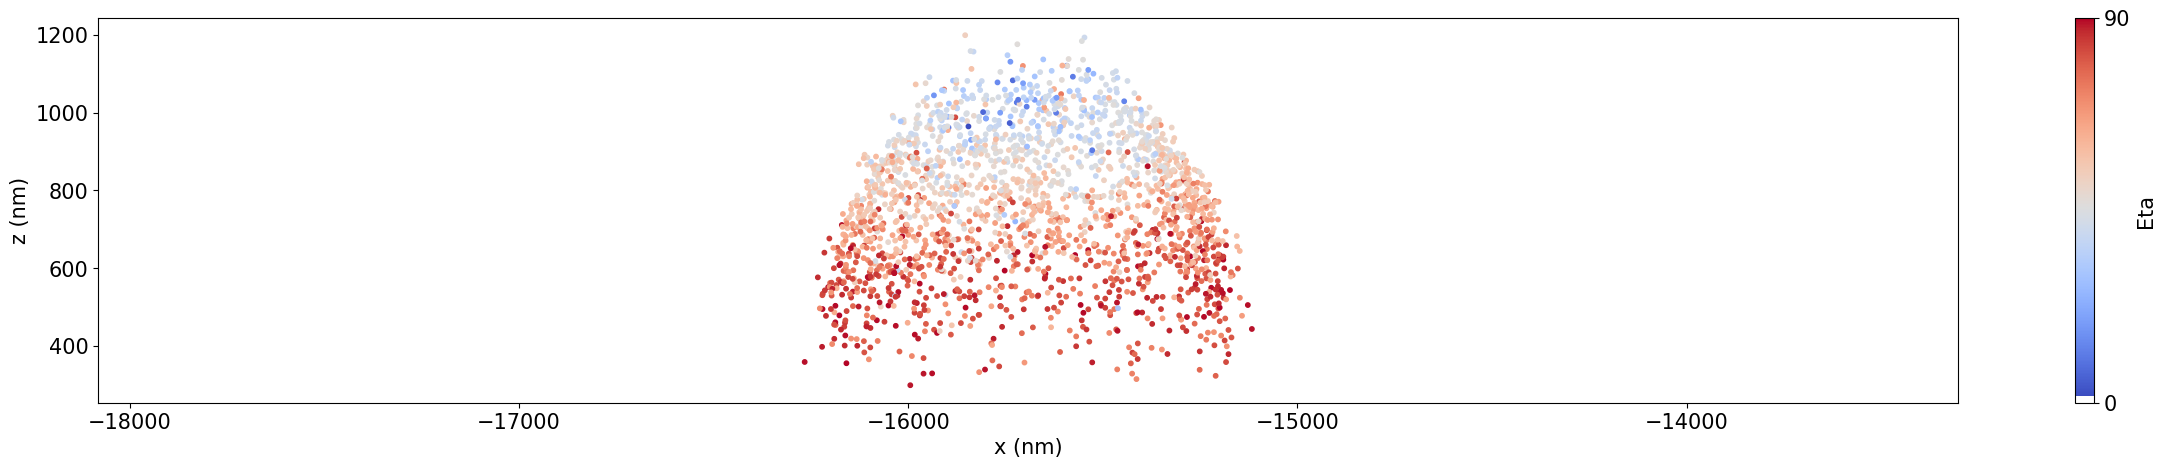

In [27]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [30,5]
normalized = eta90[mask1] / 90.0

color_data = eta90[mask1] / 90.0  # Normalize your color data


rgb_colors = hsv_to_rgb(hsv_colors)
scatter = plt.scatter(y[mask1] , z[mask1], cmap='coolwarm', c = color_data, s=10)
plt.axis('equal')

# Add colorbar
cb = plt.colorbar(scatter)
cb.set_label('Eta')
cb.set_ticks([0.0, 1.0])
cb.set_ticklabels(['0', '90'])
plt.xlabel('x (nm)')
plt.ylabel('z (nm)')
#plt.xlim((11000,22500))
#plt.ylim((500,2000))
plt.show()

(5297.26603396174, 12149.1593371905, -18490.5777891898, -3311.475680993261)

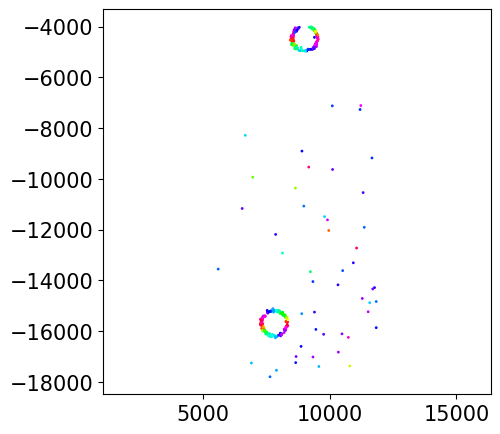

In [30]:
plt.rcParams['figure.figsize'] = [5,5]
hues = rho[zoom] / 180.0
hsv_colors = np.stack((hues, np.ones_like(hues), np.ones_like(hues)), axis=1)

rgb_colors = hsv_to_rgb(hsv_colors)
plt.scatter(x[zoom] , y[zoom] , c = rgb_colors, s=1)
plt.axis('equal')


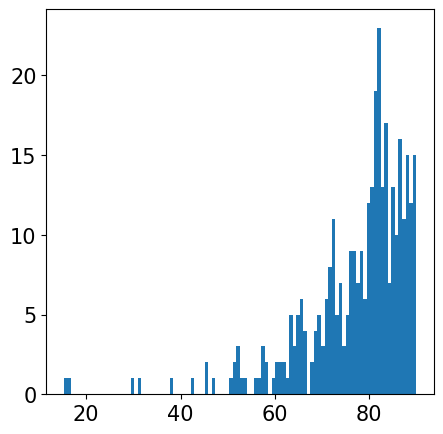

In [31]:
hh = plt.hist(eta90[zoom], bins=100)

In [28]:
new_zoom = mask1
#new_zoom = (score<loss_thresh) & (delta<150) & (N_photons>2000) & (N_photons<9000) & (x>7500) & (x<9000) & (y>-6000) & (y<-3000) & (z<1000) & (z>100)

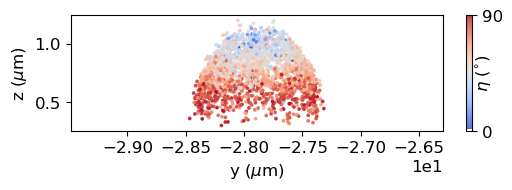

In [29]:
plt.rcParams['figure.figsize'] = [6,1.5]
plt.rcParams.update({'font.size': 12})
plt.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

y_vals = y[new_zoom]
z_vals = z[new_zoom]
color_data = eta90[new_zoom] / 90.0  # Normalize your color data
min_color_data = np.min(color_data)
# Create scatter plot with color mapping
scatter = plt.scatter(y_vals/1000-12.2, z_vals/1000, c=color_data, cmap='coolwarm', s=3, alpha=0.8)
plt.axis('equal')

# Add colorbar
cb = plt.colorbar(scatter)
cb.set_label('$\\eta$ $(^{\\circ})$', labelpad=-20, rotation=90)
cb.set_ticks([0., 1.0])
cb.set_ticklabels(['0', '90'])
plt.xlabel('y ($\\mu$m)')
plt.ylabel('z ($\\mu$m)')
#plt.xlim((0.5, 6))
#plt.ylim((0, 1.2))
#plt.savefig("eta90.svg", format="svg")
plt.show()

C:\Users\Amaury\AppData\Local\Temp\ipykernel_43580\291424589.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.set_ticklabels([str(int(10*min_color_data*90)/10), '90'])


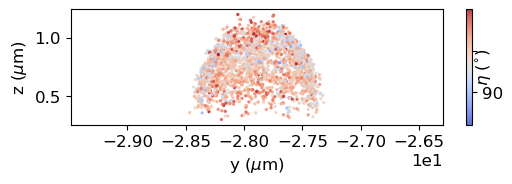

In [30]:
plt.rcParams['figure.figsize'] = [6,1.5]
plt.rcParams.update({'font.size': 12})
plt.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

y_vals = y[new_zoom]
z_vals = z[new_zoom]
color_data = delta[new_zoom] # Normalize your color data
min_color_data = np.min(color_data)
# Create scatter plot with color mapping
scatter = plt.scatter(y_vals/1000-12.2, z_vals/1000, c=color_data, cmap='coolwarm', s=2, alpha=0.8)
plt.axis('equal')

# Add colorbar
cb = plt.colorbar(scatter)
cb.set_label('$\\eta$ $(^{\\circ})$', labelpad=-20, rotation=90)
#cb.set_ticks([min_color_data, 1.0])
cb.set_ticklabels([str(int(10*min_color_data*90)/10), '90'])
plt.xlabel('y ($\\mu$m)')
plt.ylabel('z ($\\mu$m)')
#plt.xlim((0.5, 6))
#plt.ylim((0, 1.2))
#plt.savefig("imD.eps", format="eps")
plt.show()

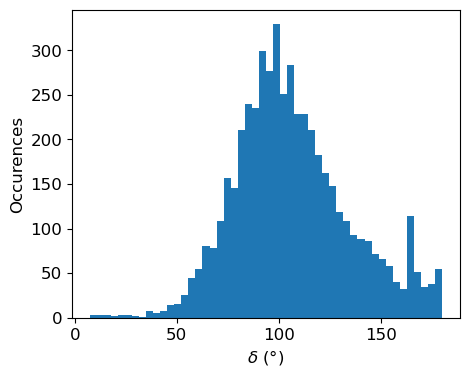

In [31]:
plt.rcParams['figure.figsize'] = [5,4]
hh = plt.hist(delta[maskdelta], bins=50)
plt.xlabel('$\\delta$ ($\\degree$)')
plt.ylabel('Occurences')
plt.savefig("delta.svg", format="svg")

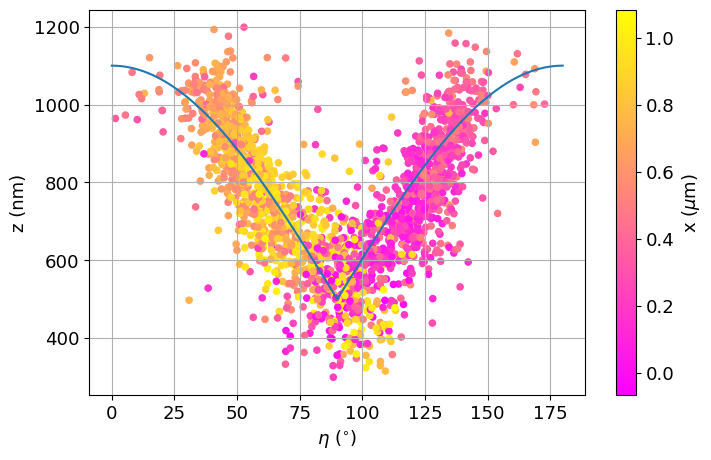

In [58]:
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams.update({'font.size': 13})
color_data = 16.2+y[new_zoom]/1000
scatter = plt.scatter(eta[new_zoom], z[new_zoom], c = color_data, cmap='spring', s=20)
cb = plt.colorbar(scatter)
etaa=np.linspace(0, 180, 500)
plt.plot(etaa, -100+600*(1+np.abs(np.cos(etaa*np.pi/180))))
cb.set_label('x ($\\mu$m)')
#cb.set_ticks([0.0, 1.0])
#cb.set_ticklabels(['0', '90'])
plt.ylabel('z (nm)')

plt.xlabel('$\\eta$ $(^{\\circ})$')
#plt.ylim((400,1800))
plt.grid()
plt.savefig("z_eta.svg", format="svg")

In [33]:
def loss__(x,y,radius,centerx, centery):
    return torch.sum(((x-centerx)**2 + (y-centery)**2-radius**2)**2)

In [34]:
def find_params(xxxx, yyyy):
    params = torch.tensor([1000.,7500.,-16000.], requires_grad=True)
    optimizer = torch.optim.Adam([params], lr=100)
    loss0 = []
    for i in tqdm(range(500)):
        optimizer.zero_grad()  # Reset gradients
        loss = loss__(torch.tensor(xxxx), torch.tensor(yyyy), params[0], params[1], params[2])
        loss0.append(loss.detach().numpy())
        loss.backward()  # Backpropagation
        optimizer.step()  # Update parameters
    plt.plot(loss0)
    plt.show()
    return params.detach().numpy()

100%|██████████| 500/500 [00:00<00:00, 1392.28it/s]


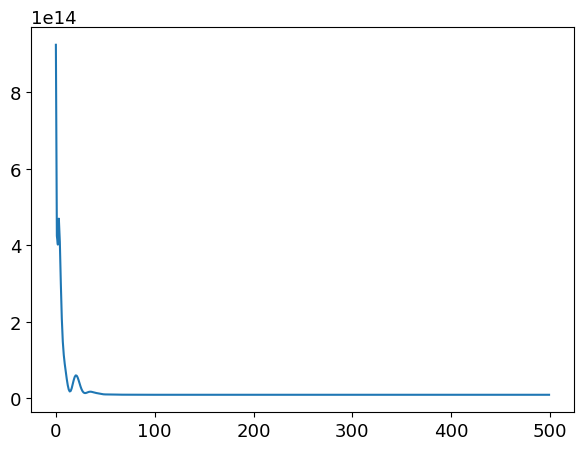

In [35]:
params = find_params(x[new_zoom].to_numpy(), y[new_zoom].to_numpy())

In [36]:
rho_th = np.arctan2(y[new_zoom]-params[2], x[new_zoom]-params[1])*(180/np.pi)%180
th = np.linspace(0,2*np.pi,100)
line = np.arctan2(params[1]+(200+params[0])*np.cos(th)-params[1], params[2]+(200+params[0])*np.sin(th)-params[2])*(180/np.pi)%180.
huesL = line / 180
hsv_colorsL = np.stack((huesL, np.ones_like(huesL), np.ones_like(huesL)), axis=1)
rgb_colorsL = hsv_to_rgb(hsv_colorsL)

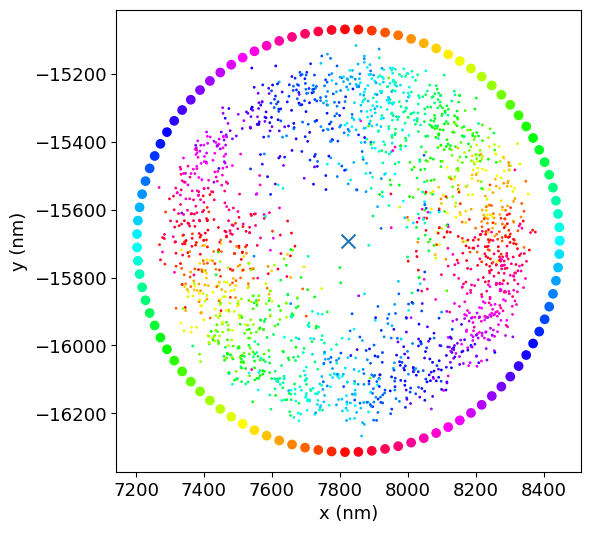

In [37]:
plt.rcParams['figure.figsize'] = [6, 6]
hues = rho[new_zoom] / 180
hsv_colors = np.stack((hues, np.ones_like(hues), np.ones_like(hues)), axis=1)
rgb_colors = hsv_to_rgb(hsv_colors)
plt.scatter(x[new_zoom], y[new_zoom], c=rgb_colors, s=1)
plt.plot()
plt.axis('equal')
plt.xlabel('x (nm)')
plt.ylabel('y (nm)')
plt.scatter(params[1], params[2], marker='x', s=100)
plt.scatter(params[1]+(200+params[0])*np.cos(th), params[2]+(200+params[0])*np.sin(th), c=rgb_colorsL)
plt.show()

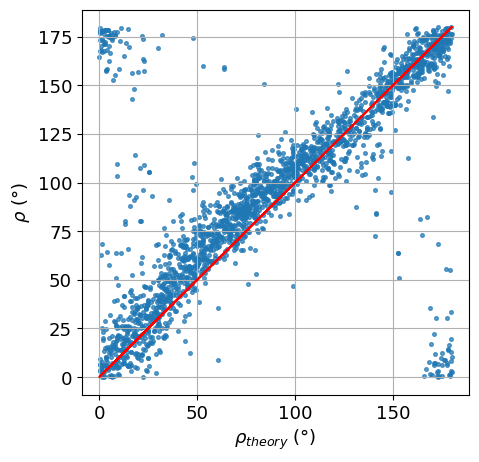

In [38]:
plt.rcParams['figure.figsize'] = [5,5]
plt.rcParams.update({'font.size': 13})
plt.scatter(rho_th, rho[new_zoom], s=7, alpha=0.7)
plt.plot(rho_th, rho_th, c='r')
plt.xlabel('$\\rho_{theory}$ ($\\degree$)')
plt.ylabel('$\\rho$ ($\\degree$)')
plt.grid()
plt.savefig("rho_exp_error.svg", format="svg")

In [ ]:
plt.rcParams['figure.figsize'] = [17,4]
plt.rcParams.update({'font.size': 10})
offset=np.mean(z[mask1])-np.mean(z_start[mask1])
h2 = plt.hist(z_start[mask1]+offset, bins=150, label='3D Gaussian fit')
h1 = plt.hist(z[mask1], bins=50, alpha=0.5, color='r', label='Gradient descent')
plt.axvline(800)
plt.grid()
plt.legend()
plt.xlim((-1200,4600))
plt.xlabel('z (nm)')
plt.ylabel('Occurences')

In [ ]:
z_start = -z_start

In [ ]:
off = 2000

In [ ]:
n1 = 1.52
n2 = 1.33
epsilon = -(0.638)/(4*0.001*(z[threshold2])*n2)
mm = np.sqrt(n1**2-n2**2)
xi = (n2/n1)*(1-epsilon-(mm/n1)*np.sqrt(epsilon*(epsilon-2)))/(1-((n2/n1)**2)*epsilon*(2-epsilon))
#xi = np.mean(xi)
print(xi)

In [ ]:
plt.rcParams['figure.figsize'] = [6,5]
plt.rcParams.update({'font.size': 10})
plt.scatter(z_start[threshold2]+off, z[threshold2], s=1)
plt.plot(z_start[threshold2]+off, (np.mean(xi))*(z_start[threshold2]+off), c='r', label='$\\zeta \\times z_{\\mathrm{A}}$')
plt.legend()
plt.xlim((-500, 3500))
plt.ylim((200, 2000))
plt.xlabel('$z_{\\mathrm{A}}$ (nm)')
plt.ylabel('$z_{\\mathrm{GD}}$ (nm)')
plt.grid()

In [ ]:
plt.rcParams['figure.figsize'] = [7,3]
plt.rcParams.update({'font.size': 11})
plt.scatter(z[threshold2], z_start[threshold2]+off, s=1)
plt.plot(z[threshold2], (1/xi)*(z[threshold2]), c='r', label='$z_{\\mathrm{GD}} / \\zeta$')
plt.legend()
plt.xlim((400, 1700))
plt.ylim((200, 2500))
plt.xlabel('$z_{\\mathrm{GD}}$ (nm)')
plt.ylabel('$z_{\\mathrm{A}}$ (nm)')
plt.grid()

In [ ]:
plt.rcParams['figure.figsize'] = [7,3]
plt.rcParams.update({'font.size': 11})
plt.scatter(rho_start[threshold3], (rho[threshold3]-20)%180, s=2)
plt.xlim((0, 180))
plt.ylim((0, 180))
plt.ylabel('$\\rho_{\\mathrm{GD}}$ ($^{\\circ}$)')
plt.xlabel('$\\rho_{\\mathrm{Ratiometric}}$ ($^{\\circ}$)')
plt.grid()

In [ ]:
plt.rcParams['figure.figsize'] = [7,3]
plt.rcParams.update({'font.size': 11})
plt.scatter(delta_start[threshold4], delta[threshold4], s=2)
plt.plot(delta_start[threshold4], delta_start[threshold4], c='r', label='$\\delta_{\\mathrm{GD}}=\\delta_{\\mathrm{Ratiometric}}$')
plt.legend()
plt.ylim((60, 180))
plt.xlim((0, 180))
plt.ylabel('$\\delta_{\\mathrm{GD}}$ ($^{\\circ}$)')
plt.xlabel('$\\delta_{\\mathrm{Ratiometric}}$ ($^{\\circ}$)')
plt.grid()

In [ ]:
plt.rcParams['figure.figsize'] = [7,3]
plt.rcParams.update({'font.size': 11})
plt.scatter(z[threshold2], delta[threshold2], s=1)
plt.legend()
plt.xlim((400, 1700))
#plt.ylim((200, 2500))
plt.xlabel('$z_{\\mathrm{GD}}$ (nm)')
plt.ylabel('$z_{\\mathrm{A}}$ (nm)')
plt.grid()

In [ ]:
plt.rcParams['figure.figsize'] = [7,3]
hist = plt.hist(delta[mask1], bins=80, label='Gradient descent')
hist = plt.hist(delta_start[mask1], bins=80, alpha=0.5, label='Ratiometric method', color='g')
plt.legend()
plt.xlabel('$\\delta$ $(^{\\circ})$')
plt.ylabel('Occurences')